In [9]:
# Importing all the necessary packages. 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

import tensorflow as tf
from keras import models
from keras import layers
from tensorflow import keras
from tensorflow.keras import layers, regularizers

import warnings
warnings.filterwarnings("ignore")

In [10]:
# Load in the train, val, and test datasets
X_train = pd.read_csv("./../data/X_train.csv")
Y_train = pd.read_csv("./../data/Y_train.csv")

X_val = pd.read_csv("./../data/X_val.csv")
Y_val = pd.read_csv("./../data/Y_val.csv")

X_test = pd.read_csv("./../data/X_test.csv")
Y_test = pd.read_csv("./../data/Y_test.csv")

# Check shape: confirm 60/20/20 split and confirm 15 features for X and 1 outcome variable for Y
print(f"""
shape of X_train: {X_train.shape}
shape of Y_train: {Y_train.shape}
shape of X_val: {X_val.shape}
shape of Y_val: {Y_val.shape}
shape of X_test: {X_test.shape}
shape of Y_test: {Y_test.shape}
""")


shape of X_train: (15404, 15)
shape of Y_train: (15404, 1)
shape of X_val: (5147, 15)
shape of Y_val: (5147, 1)
shape of X_test: (5140, 15)
shape of Y_test: (5140, 1)



In [11]:
# Standardize numeric features (13) and set "passthrough" for remaining binary features (2)
numeric_cols = ["elo_diff", "elo_sum", "home_team_h2h_wins", "away_team_h2h_wins", "h2h_draws",
                "rank_diff", "rank_sum", "home_count_last5", "away_count_last5", "pts_pg_diff_last5",
                "pts_pg_sum_last5", "gf_pg_diff_last5", "ga_pg_diff_last5"]
# binary_cols = ["neutral", "is_friendly"]

preprocessor = ColumnTransformer(
    transformers=[("standardized", StandardScaler(), numeric_cols)], remainder="passthrough")

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed   = preprocessor.transform(X_val)
X_test_processed  = preprocessor.transform(X_test)

In [12]:
# Build FFNN model
tf.random.set_seed(1)
tf.keras.backend.clear_session()

model = tf.keras.Sequential()
model.add(tf.keras.Input(shape=(X_train_processed.shape[1],)))
model.add(tf.keras.layers.Dense(units=256, activation='relu'))
model.add(tf.keras.layers.Dense(units=128, activation='relu'))
model.add(tf.keras.layers.Dense(units=64, activation='relu'))
model.add(tf.keras.layers.Dense(units=3, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,443 (177.51 KB)

 Trainable params: 45,443 (177.51 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
epochs = 20
learning_rate = 0.002

# Compile model
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=learning_rate),
               loss="sparse_categorical_crossentropy",
               metrics=["accuracy"])

# Train model
history = model.fit(X_train_processed, Y_train,
                   validation_data=(X_val_processed, Y_val),
                   epochs=epochs, batch_size=64, verbose=1)

Epoch 1/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4551 - loss: 1.0424 - val_accuracy: 0.5527 - val_loss: 0.9546
Epoch 2/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5701 - loss: 0.9261 - val_accuracy: 0.5862 - val_loss: 0.9072
Epoch 3/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5858 - loss: 0.8971 - val_accuracy: 0.5914 - val_loss: 0.8899
Epoch 4/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5900 - loss: 0.8847 - val_accuracy: 0.5959 - val_loss: 0.8812
Epoch 5/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5950 - loss: 0.8780 - val_accuracy: 0.6000 - val_loss: 0.8759
Epoch 6/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5976 - loss: 0.8736 - val_accuracy: 0.6007 - val_loss: 0.8722
Epoch 7/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6002 - loss: 0.8705 - val_accuracy: 0.6002 - val_loss: 0.8694
Epoch 8/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6007 - loss: 0.8681 - val_accuracy: 0.

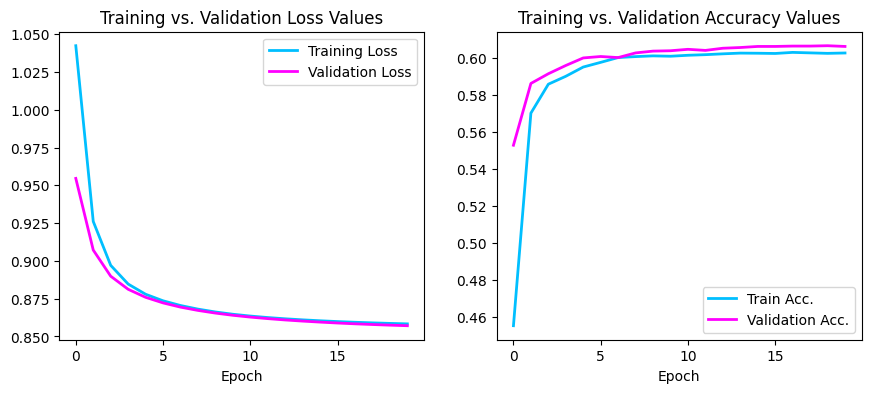

In [14]:
# Plot Loss
fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 3, 1)
plt.plot(history.history['loss'], lw=2, color='deepskyblue')
plt.plot(history.history['val_loss'], lw=2, color='fuchsia')
plt.legend(['Training Loss', 'Validation Loss'], fontsize=10)
ax.set_xlabel('Epoch', size=10)
ax.set_title('Training vs. Validation Loss Values')

# Plot Accuracy
ax = fig.add_subplot(1, 3, 2)
plt.plot(history.history['accuracy'], lw=2, color='deepskyblue')
plt.plot(history.history['val_accuracy'], lw=2, color='fuchsia')
plt.legend(['Train Acc.', 'Validation Acc.'], fontsize=10)
ax.set_xlabel('Epoch', size=10)
ax.set_title('Training vs. Validation Accuracy Values')
plt.show()

In [15]:
# Calculate Training and Test Loss / Accuracy
train_loss_eval, train_accuracy_eval =  model.evaluate(x=X_train_processed, y=Y_train, verbose = 0)
print(f"Training loss: {train_loss_eval:.4f}")
print(f"Training accuracy: {train_accuracy_eval:.4f}")

test_loss_eval, test_accuracy_eval = model.evaluate(x=X_test_processed, y=Y_test, verbose = 0)
print(f"\nTest loss: {test_loss_eval:.4f}")
print(f"Test accuracy: {test_accuracy_eval:.4f}")

Training loss: 0.8578
Training accuracy: 0.6023

Test loss: 0.8550
Test accuracy: 0.6082


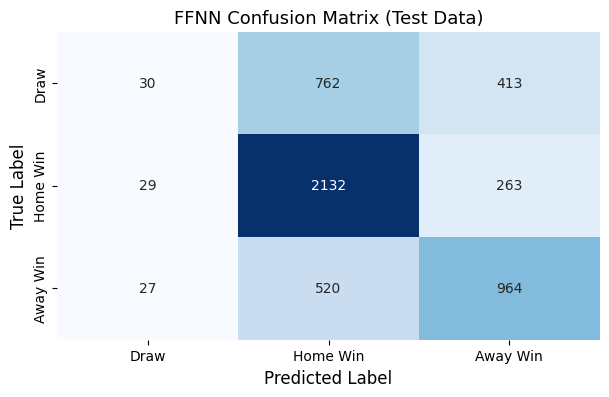

Precision and Recall per Class:
- Draw: Precision = 0.35, Recall = 0.02
- Home Win: Precision = 0.62, Recall = 0.88
- Away Win: Precision = 0.59, Recall = 0.64

Largest source of false positives is 'Home Win' with 1282 false positives.
Largest source of false negatives is 'Draw' with 1175 false negatives.


In [16]:
# Predict on test data and get predicted class label
test_preds = model.predict(X_test_processed, verbose = 0)
test_preds_labels = np.argmax(test_preds, axis=1)

# Plot confusion matrix for test predictions
cm = tf.math.confusion_matrix(Y_test, test_preds_labels)
class_names = ['Draw', 'Home Win', 'Away Win']
plt.figure(figsize=(7,4))
ax = sns.heatmap(cm, annot=True, fmt='.4g', cmap='Blues',
                 xticklabels=class_names,
                 yticklabels=class_names, cbar=False)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.title("FFNN Confusion Matrix (Test Data)", fontsize=13)
plt.show()

# Calculate Precision and Recall
# True positives: diagonal line (top left to bottom right)
TP = np.diag(cm)

# False positives: column sum (total positive predictions for a single class) - TP
FP = np.sum(cm, axis=0) - TP

# False negatives: row sum (total true positives for a single class) - TP
FN = np.sum(cm, axis=1) - TP

# Precision: out of all predicted positives (TP + FP), how many were predicted correctly (TP)
# Recall: out of all true positives (TP + FN), how many were predicted correctly (TP)
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("Precision and Recall per Class:")
for i in range(len(cm)):
    print(f"- {class_names[i]}: Precision = {precision[i]:.2f}, Recall = {recall[i]:.2f}")

print(f"\nLargest source of false positives is '{class_names[np.argmax(FP)]}' with {max(FP)} false positives.")
print(f"Largest source of false negatives is '{class_names[np.argmax(FN)]}' with {max(FN)} false negatives.")